In [ ]:
import os
import math
import h5py
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader as TorchDataLoader
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import EdgeConv, global_mean_pool, global_max_pool
from torch_geometric.utils import degree, to_networkx, to_undirected

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [97]:
FILE_PATH = "datasets/quark-gluon_data-set_n139306.hdf5"
MAIN_K = 8
MAIN_CACHE_FILE = f"datasets/qg_graph_dataset_k{MAIN_K}_edgeattr.pt"

# set division
VAL_SIZE = 0.15
TEST_SIZE = 0.15

BATCH_SIZE = 32

EPOCHS = 20
BASELINE_EPOCHS = 8

LR = 1e-4
WEIGHT_DECAY = 1e-4

DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [4]:
with h5py.File(FILE_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    X = f["X_jets"][:]
    y = np.asarray(f["y"][:]).reshape(-1).astype(np.int64)
    pt = np.asarray(f["pt"][:]).reshape(-1).astype(np.float32)
    m0 = np.asarray(f["m0"][:]).reshape(-1).astype(np.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("pt shape:", pt.shape)
print("m0 shape:", m0.shape)

unique, counts = np.unique(y, return_counts=True)
print("Class counts:", dict(zip(unique.tolist(), counts.tolist())))

Keys: ['X_jets', 'm0', 'pt', 'y']
X shape: (139306, 125, 125, 3)
y shape: (139306,)
pt shape: (139306,)
m0 shape: (139306,)
Class counts: {0: 69653, 1: 69653}


class are equaly proportional = 50% each
# EDA

In [5]:
# variation of pt and m0
# for note (and learning): pt is transverse momentum and m0 is invariant mass
print(pt.min(), pt.max(), pt.mean())
print(m0.min(), m0.max(), m0.mean())

70.11005 337.05173 117.12393
3.3729308 75.95049 21.39222


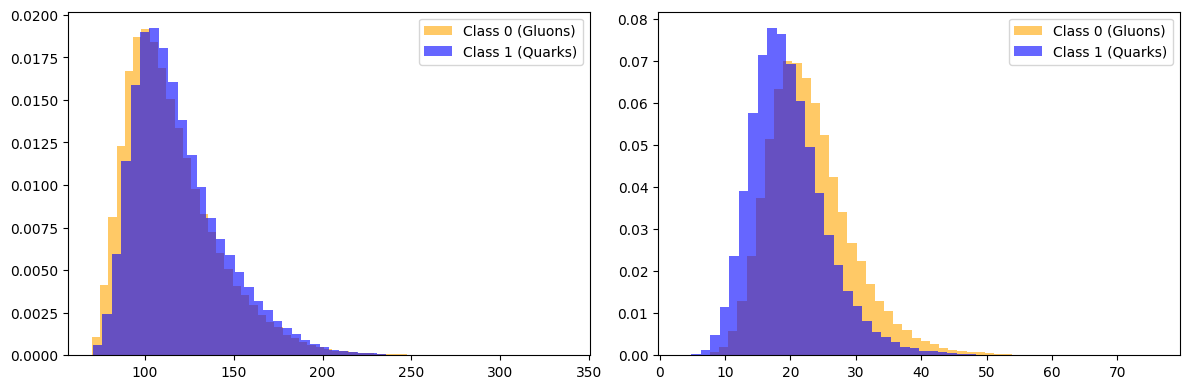

In [6]:
def plot_pt_m0(pt, m0, y):
    fig, ax = plt.subplots(1, 2, figsize=(12,4))

    ax[0].hist(pt[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax[0].hist(pt[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax[0].legend()

    ax[1].hist(m0[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax[1].hist(m0[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_pt_m0(pt, m0, y)

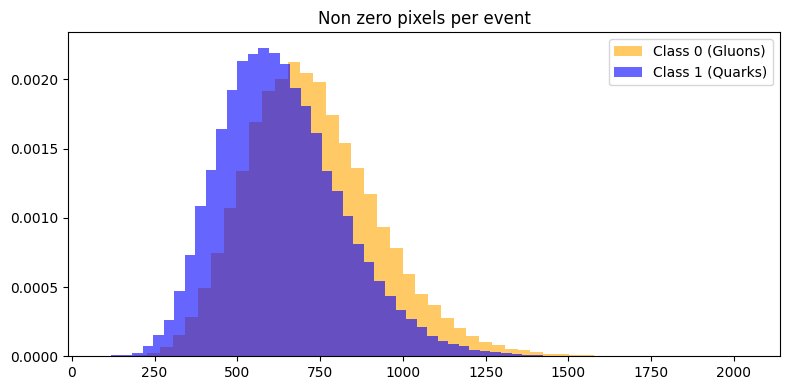

Gluon — mean: 727.9 | median: 709.0
Quark — mean: 634.6 | median: 616.0
Sparsity - Gluon — mean: 0.9534 | median: 0.9546
Sparsity - Quark — mean: 0.9594 | median: 0.9606


In [7]:
def to_hwc(image):
    image = np.asarray(image)
    if image.ndim == 2:
        return image[..., None]
    if image.ndim != 3:
        raise ValueError(f'Unexpected image shape: {image.shape}')
    if image.shape[0] <= 6 and image.shape[1] > 6 and image.shape[2] > 6:
        image = np.transpose(image, (1, 2, 0))
    return image

def plot_nonzero(X, y):
    non_zero_counts = []
    sparsity = []
    for img in X:
        img_hwc = to_hwc(img)
        activity = img_hwc.sum(axis=-1)
        non_zero_counts.append(np.count_nonzero(activity > 0))
        total_pixels = img_hwc.shape[0] * img_hwc.shape[1]
        sparsity.append(1 - np.count_nonzero(activity > 0) / total_pixels)
    non_zero_counts = np.array(non_zero_counts)
    sparsity = np.array(sparsity)

    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(non_zero_counts[y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(non_zero_counts[y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()
    ax.set_title('Non zero pixels per event')

    plt.tight_layout()
    plt.show()

    for cls, name in [(0, "Gluon"), (1, "Quark")]:
        mask = y == cls
        print(f"{name} — mean: {non_zero_counts[mask].mean():.1f} | median: {np.median(non_zero_counts[mask]):.1f}")

    for cls, name in [(0, "Sparsity - Gluon"), (1, "Sparsity - Quark")]:
        mask = y == cls
        print(f"{name} — mean: {sparsity[mask].mean():.4f} | median: {np.median(sparsity[mask]):.4f}")
plot_nonzero(X, y)

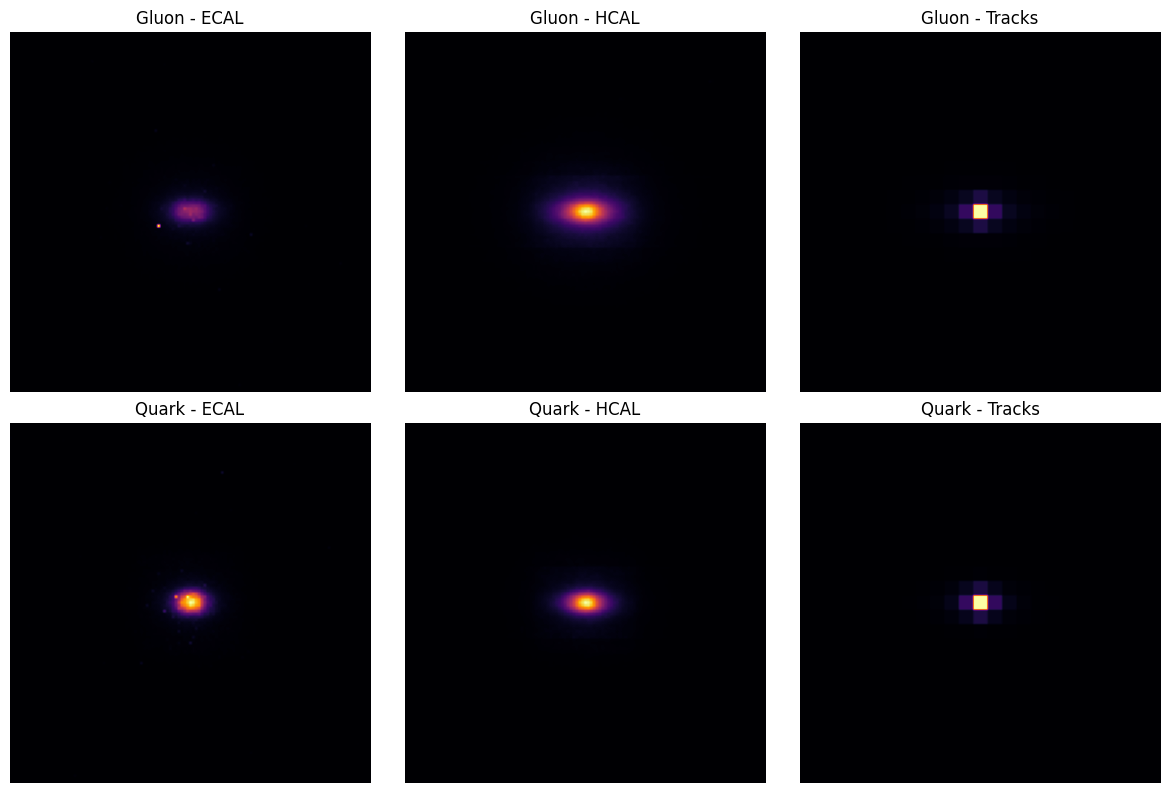

In [8]:
# channel intensity
X_hwc = np.array([to_hwc(img) for img in X])

mean_img_gluon = X_hwc[y == 0].mean(axis=0)
mean_img_quark = X_hwc[y == 1].mean(axis=0)

channel_names = ['ECAL', 'HCAL', 'Tracks']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ch in range(3):
    axes[0, ch].imshow(mean_img_gluon[:, :, ch], cmap='inferno')
    axes[0, ch].set_title(f"Gluon - {channel_names[ch]}")
    axes[0, ch].axis('off')

    axes[1, ch].imshow(mean_img_quark[:, :, ch], cmap='inferno')
    axes[1, ch].set_title(f"Quark - {channel_names[ch]}")
    axes[1, ch].axis('off')

plt.tight_layout()
plt.show()

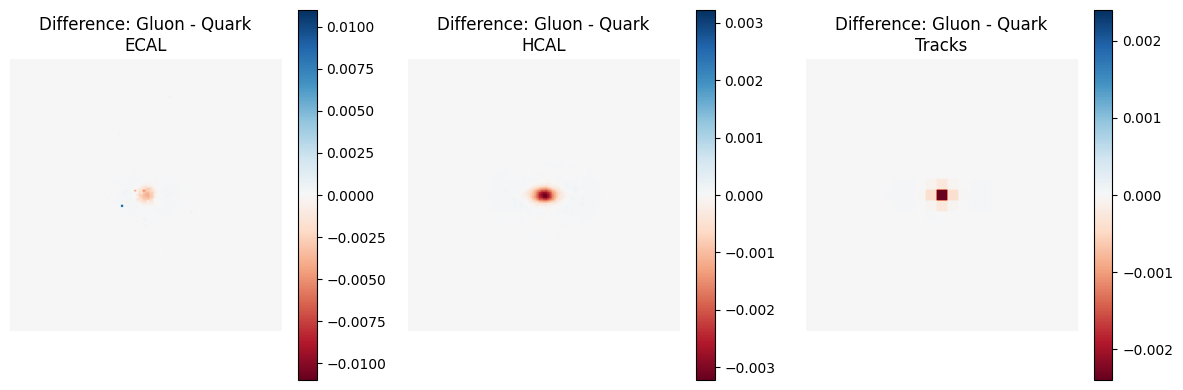

In [9]:
# diff map
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

diff = mean_img_gluon - mean_img_quark

for ch in range(3):
    im = axes[ch].imshow(diff[:, :, ch], cmap="RdBu", vmin=-np.abs(diff[:,:,ch]).max(), vmax=np.abs(diff[:,:,ch]).max())
    axes[ch].set_title(f"Difference: Gluon - Quark\n{channel_names[ch]}")
    axes[ch].axis("off")
    plt.colorbar(im, ax=axes[ch])

plt.tight_layout()
plt.show()

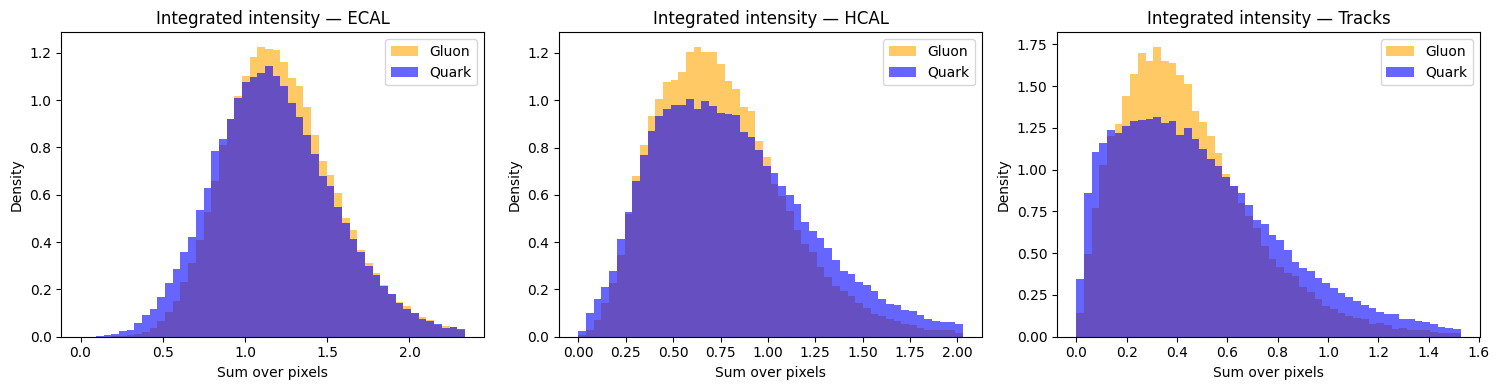

In [10]:
def plot_channel_intensity(X_hwc, y):
    channel_sum = X_hwc.sum(axis=(1,2))
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ch in range(3):
        xmax = np.percentile(channel_sum[:, ch], 99)
        axes[ch].hist(channel_sum[y == 0, ch], bins= 50, alpha= .6, color='orange', density=True, label='Gluon', range=(0, xmax))
        axes[ch].hist(channel_sum[y == 1, ch], bins= 50, alpha= .6, color='blue', density=True, label='Quark', range=(0, xmax))

        axes[ch].set_title(f"Integrated intensity — {channel_names[ch]}")
        axes[ch].set_xlabel("Sum over pixels")
        axes[ch].set_ylabel("Density")
        axes[ch].legend()

    plt.tight_layout()
    plt.show()

plot_channel_intensity(X_hwc, y)

In [11]:
# graph construction
def graph_const(img, label):
    img = to_hwc(img)
    activity = img.sum(axis=-1)
    ys, xs = np.nonzero(activity > 0)

    if len(xs) == 0:
        return Data(
            x=torch.zeros((1, 6), dtype=torch.float32),
            pos=torch.zeros((1, 2), dtype=torch.float32),
            edge_index=torch.zeros((2, 0), dtype=torch.long),
            edge_attr=torch.zeros((0, 4), dtype=torch.float32),
            y=torch.tensor(label, dtype=torch.long)
        )

    pixel_values = img[ys, xs, :].astype(np.float32)
    
    norm_intensity = pixel_values / (np.sum(pixel_values) + 1e-12)
    x_norm = (xs / (img.shape[1] - 1)).astype(np.float32)
    y_norm = (ys / (img.shape[0] - 1)).astype(np.float32)

    #centroid
    weights = norm_intensity.sum(axis=1)
    cx = np.sum(xs * weights) / np.sum(weights)
    cy = np.sum(ys * weights) / np.sum(weights)
    
    r = np.sqrt(((xs - cx) ** 2) + ((ys - cy) ** 2))
    r_norm = (r / np.sqrt((img.shape[0] ** 2) + (img.shape[1] ** 2))).astype(np.float32)

    node_features = np.concatenate([
        norm_intensity,
        x_norm[:, None],
        y_norm[:, None],
        r_norm[:, None]
    ], axis=1)

    #nearesneighbors
    pos = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

    neigh = NearestNeighbors(n_neighbors=(max(1, min(MAIN_K, len(xs) - 1))))
    neigh.fit(pos)
    dist, indices = neigh.kneighbors(X=pos)

    #edges
    edges = []
    attrs = []
    for i, neighbours in enumerate(indices):
        for j in neighbours[1:]:
            edges.append([i, j])

            #edge features
            dx = pos[j, 0] - pos[i, 0]
            dy = pos[j, 1] - pos[i, 1]
            edge_dist = np.sqrt(pow(dx, 2) + pow(dy, 2))
            dint = weights[j] - weights[i]

            attrs.append([dx,dy, edge_dist, dint])
    

    edges_tensor = torch.tensor(edges, dtype=torch.long)
    edges_attr_tensor = torch.tensor(attrs, dtype=torch.float32)

    edges_index = edges_tensor.t().contiguous()

    edge_index, edge_attr = to_undirected(
        edge_index=edges_index,
        edge_attr=edges_attr_tensor,
        num_nodes=len(xs)
    )
    edge_index = edge_index.to(torch.int32)
    #Data object
    node_features_t = torch.tensor(node_features, dtype=torch.float32)
    pos_t = torch.tensor(pos, dtype=torch.float32)
    label_t = torch.tensor(label, dtype=torch.long)
    G = Data(x=node_features_t, y=label_t, edge_index=edge_index, edge_attr=edge_attr, pos=pos_t)
    return G

In [12]:
del X_hwc
import gc
gc.collect()

72907

In [13]:
def build_graphs(X, y, cache_file):
    if os.path.exists(cache_file):
        return torch.load(cache_file, weights_only=False)
    else:
        graphs = []
        for img, label in tqdm(zip(X, y), total=len(X), desc="Building graphs"):
            graphs.append(graph_const(img, label))
            
        torch.save(graphs, cache_file)
        return graphs

In [14]:
graphs = build_graphs(X, y, cache_file=MAIN_CACHE_FILE)

Building graphs: 100%|██████████| 139306/139306 [23:15<00:00, 99.83it/s] 


In [15]:
print(f"Total graphs: {len(graphs)}")
print(graphs[0])

Total graphs: 139306
Data(x=[884, 6], edge_index=[2, 7610], edge_attr=[7610, 4], y=0, pos=[884, 2])


In [17]:
print(f"Total graphs: {len(graphs)}")
print(f"Example: {graphs[0]}")
print(f"Label distribution: {sum(g.y.item() for g in graphs[:1000])} quarks in first 1000")

Total graphs: 139306
Example: Data(x=[884, 6], edge_index=[2, 7610], edge_attr=[7610, 4], y=0, pos=[884, 2])
Label distribution: 518 quarks in first 1000


In [22]:
# graph EDA
sample_idx = np.where(y == 0)[0][:1000].tolist() + np.where(y == 1)[0][:1000].tolist()
sampled_graphs = [graphs[i] for i in sample_idx]
sampled_y = y[sample_idx]

nodes_per_graph = []
edges_per_graph = []

for g in sampled_graphs:
    nodes_per_graph.append(g.num_nodes)
    
nodes_per_graph = np.array(nodes_per_graph)

for g in sampled_graphs:
    edges_per_graph.append(g.num_edges)
    
edges_per_graph = np.array(edges_per_graph)
    

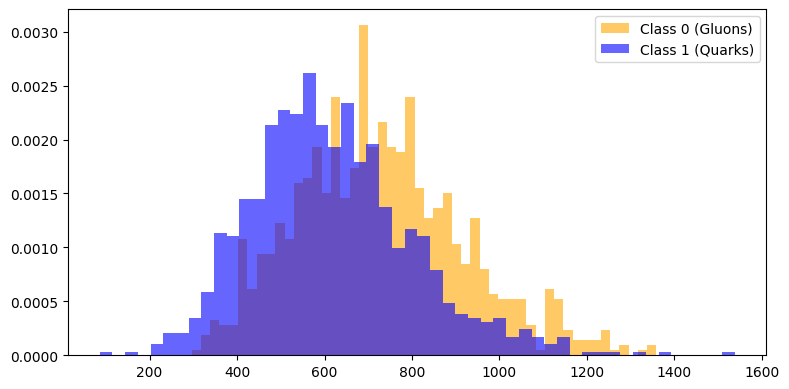

In [20]:
def plot_nodes_class(nodes_per_graph, sampled_y):
    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(nodes_per_graph[sampled_y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(nodes_per_graph[sampled_y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_nodes_class(nodes_per_graph, sampled_y)

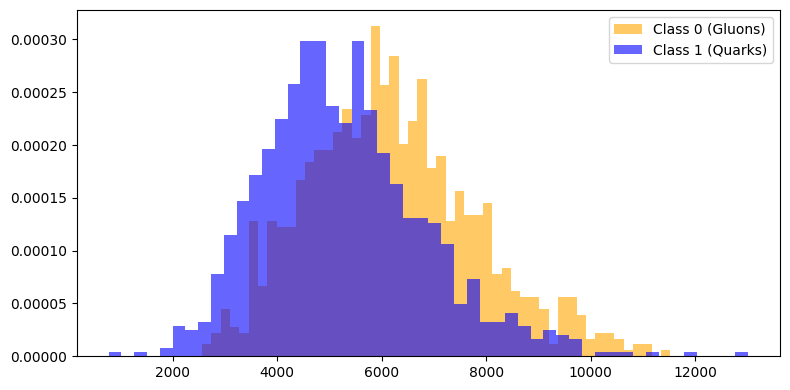

In [33]:
def plot_edges_class(edges_per_graph, sampled_y):
    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(edges_per_graph[sampled_y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(edges_per_graph[sampled_y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_edges_class(edges_per_graph, sampled_y)

In [29]:
degree_per_graph = []

for g in sampled_graphs:
    avg_degree = degree(g.edge_index[0], num_nodes=g.num_nodes).mean().item()
    degree_per_graph.append(avg_degree)

degree_per_graph = np.array(degree_per_graph)

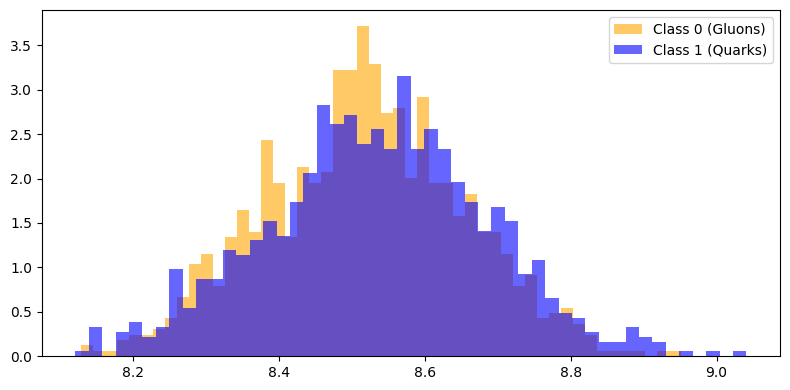

In [34]:
def plot_avg_degree(degree_per_graph, sampled_y):
    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(degree_per_graph[sampled_y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(degree_per_graph[sampled_y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_avg_degree(degree_per_graph, sampled_y)

In [36]:
num_conn_components = []

for g in sampled_graphs:
    G = to_networkx(g, to_undirected=True)
    num_conn_components.append(nx.number_connected_components(G))

num_conn_components = np.array(num_conn_components)

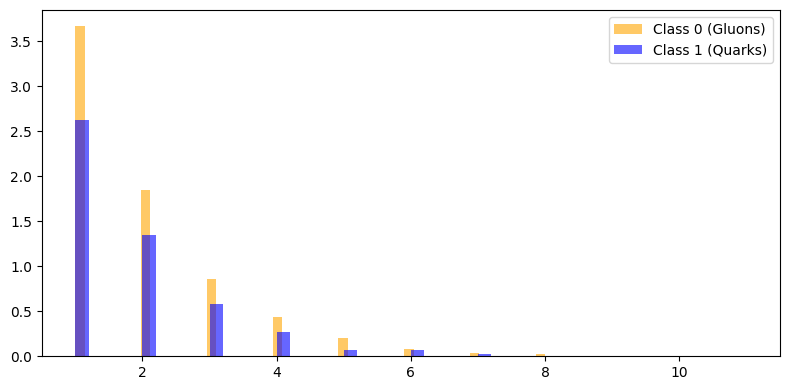

In [37]:
def plot_num_conn_components(num_conn_components, sampled_y):
    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(num_conn_components[sampled_y == 0], bins=50, alpha=0.6, color='orange', label='Class 0 (Gluons)', density=True)
    ax.hist(num_conn_components[sampled_y == 1], bins=50, alpha=0.6, color='blue', label='Class 1 (Quarks)', density=True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_num_conn_components(num_conn_components, sampled_y)

In [38]:
#stratified split
train_idx, temp_idx = train_test_split(np.arange(len(graphs)), test_size=VAL_SIZE + TEST_SIZE, stratify=y)

val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y[temp_idx])

In [39]:
train_graphs = [graphs[i] for i in train_idx]
val_graphs = [graphs[i] for i in val_idx]
test_graphs = [graphs[i] for i in test_idx]

In [40]:
train_loader = PyGDataLoader(train_graphs,batch_size=BATCH_SIZE, shuffle=True)
val_loader = PyGDataLoader(val_graphs,batch_size=BATCH_SIZE, shuffle=False)
test_loader = PyGDataLoader(test_graphs,batch_size=BATCH_SIZE, shuffle=False)

In [41]:
#baseline logistic regression
X_train_lr = []
X_test_lr = []
X_val_lr = []

for g in train_graphs:
    g_mean_pool = g.x.numpy().mean(axis=0)
    X_train_lr.append(g_mean_pool)

for g in test_graphs:
    g_mean_pool = g.x.numpy().mean(axis=0)
    X_test_lr.append(g_mean_pool)

for g in val_graphs:
    g_mean_pool = g.x.numpy().mean(axis=0)
    X_val_lr.append(g_mean_pool)

X_train_lr = np.array(X_train_lr)
X_test_lr = np.array(X_test_lr)
X_val_lr = np.array(X_val_lr)

y_train_lr = y[train_idx]
y_test_lr = y[test_idx]
y_val_lr = y[val_idx]

In [42]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X_train_lr, y_train_lr)

y_pred_lr = clf.predict(X_test_lr)
y_prob_lr = clf.predict_proba(X_test_lr)[: , 1]

/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/felipetomepereira/Projects/ml4sci-test/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/User

In [45]:
print(f'Accuracy: {accuracy_score(y_test_lr, y_pred_lr)}')
print(f'F1 Score: {f1_score(y_test_lr, y_pred_lr)}')
print(f'AUC: {roc_auc_score(y_test_lr, y_prob_lr)}')

Accuracy: 0.5120118683001531
F1 Score: 0.5091696750902527
AUC: 0.5151659428653007


In [63]:
class JetImageDataset(Dataset):
    def __init__(self, X, y, indices):
        super().__init__()
        self.X = X
        self.y = y
        self.indices = indices
    
    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = self.indices[idx]
        img = to_hwc(self.X[i])
        img = np.transpose(img, (2, 0, 1))
        img = torch.tensor(img, dtype=torch.float32)
        label = torch.tensor(self.y[i], dtype=torch.long)
        return img, label

In [64]:
train_img_dataset = JetImageDataset(X, y, train_idx)
val_img_dataset = JetImageDataset(X, y, val_idx)
test_img_dataset = JetImageDataset(X, y, test_idx)

In [65]:
train_loader_cnn = TorchDataLoader(train_img_dataset,batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn = TorchDataLoader(val_img_dataset,batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn = TorchDataLoader(test_img_dataset,batch_size=BATCH_SIZE, shuffle=False)

In [66]:
class SmallCNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        out = self.classifier(x)
        return out

In [67]:
cnn_model = SmallCNN(in_channels=3).to(DEVICE)

In [68]:
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max')

In [73]:
best_val_auc = -1
patience = 3
patience_counter = 0
best_model_path = "models/best_cnn.pt"

In [70]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    total_items = 0
    
    for images, labels in tqdm(loader, desc=f"Training", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_items += labels.size(0)
    
    return total_loss / total_items

In [71]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        all_y_true.append(labels.cpu().numpy())
        all_y_pred.append(preds.cpu().numpy())
        all_y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)
    y_prob = np.concatenate(all_y_prob)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    pos_rate = y_pred.mean()

    return {
        "accuracy": acc,
        "f1": f1,
        "auc": auc,
        "pos_rate": pos_rate,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

In [72]:
history = []
for epoch in range(1, BASELINE_EPOCHS + 1):
    train_loss = train_one_epoch(cnn_model, train_loader_cnn, optimizer, criterion)
    val_metrics = evaluate(cnn_model, val_loader_cnn)
    scheduler.step(val_metrics["auc"])

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_auc': val_metrics['auc'],
        'val_f1': val_metrics['f1'],
        'val_acc': val_metrics['accuracy']
    })

    print(
        f"Epoch {epoch:02d}/{BASELINE_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_auc={val_metrics['auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        patience_counter = 0
        torch.save(cnn_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 01/20 | train_loss=0.6670 | val_auc=0.7431 | val_f1=0.6779 | val_acc=0.6849 | 


Epoch 02/20 | train_loss=0.6149 | val_auc=0.7442 | val_f1=0.6958 | val_acc=0.6875 | 


Epoch 03/20 | train_loss=0.6107 | val_auc=0.7451 | val_f1=0.6952 | val_acc=0.6876 | 


Epoch 04/20 | train_loss=0.6038 | val_auc=0.7450 | val_f1=0.7037 | val_acc=0.6854 | 


Epoch 05/20 | train_loss=0.6034 | val_auc=0.7457 | val_f1=0.7062 | val_acc=0.6851 | 


Epoch 06/20 | train_loss=0.6001 | val_auc=0.7464 | val_f1=0.6979 | val_acc=0.6879 | 


Epoch 07/20 | train_loss=0.6005 | val_auc=0.7467 | val_f1=0.6951 | val_acc=0.6884 | 


Epoch 08/20 | train_loss=0.5992 | val_auc=0.7470 | val_f1=0.6975 | val_acc=0.6881 | 


In [74]:
cnn_model.load_state_dict(torch.load(best_model_path))
test_metrics_cnn = evaluate(cnn_model, test_loader_cnn)

print(f"Accuracy: {test_metrics_cnn['accuracy']:.4f}")
print(f"F1: {test_metrics_cnn['f1']:.4f}")
print(f"AUC: {test_metrics_cnn['auc']:.4f}")

Accuracy: 0.6866
F1: 0.6965
AUC: 0.7471


In [ ]:
# main model
class JetEdgeConvNet(nn.Module):
    def __init__(self, in_channels, hidden_channels = 64, num_classes = 2):
        super().__init__()

        self.conv1 = EdgeConv(
            nn.Sequential(
                nn.Linear(2 * in_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU()
            )
        )

        self.bn1 = nn.BatchNorm1d(hidden_channels)

        self.conv2 = EdgeConv(
            nn.Sequential(
                nn.Linear(2 * hidden_channels, hidden_channels),
                nn.ReLU(),
                nn.Linear(hidden_channels, hidden_channels),
                nn.ReLU()
            )
        )

        self.bn2 = nn.BatchNorm1d(hidden_channels)

        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_channels, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)

        x_mean_pool = global_mean_pool(x, batch)
        x_max_pool = global_max_pool(x, batch)

        x = torch.cat([x_mean_pool, x_max_pool], dim=1)

        out = self.classifier(x)
        return out
    

In [98]:
best_model_path = "models/best_gnn.pt"

gnn_model = JetEdgeConvNet(in_channels=graphs[0].x.shape[1]).to(DEVICE)

gnn_optimizer = torch.optim.Adam(gnn_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
gnn_criterion = nn.CrossEntropyLoss()
gnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(gnn_optimizer, mode='max')

In [99]:
def train_one_epoch_gnn(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    total_graphs = 0
    
    for batch in tqdm(loader, desc=f"Training", leave=False):
        batch = batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(logits, batch.y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * batch.num_graphs
        total_graphs += batch.num_graphs

    return total_loss / total_graphs

In [100]:
@torch.no_grad()
def evaluate_gnn(model, loader):
    model.eval()

    all_y_true = []
    all_y_pred = []
    all_y_prob = []

    for batch in loader:
        batch = batch.to(DEVICE)

        logits = model(batch.x, batch.edge_index, batch.batch)
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        all_y_true.append(batch.y.cpu().numpy())
        all_y_pred.append(preds.cpu().numpy())
        all_y_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)
    y_prob = np.concatenate(all_y_prob)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = float("nan")

    pos_rate = y_pred.mean()

    return {
        "accuracy": acc,
        "f1": f1,
        "auc": auc,
        "pos_rate": pos_rate,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }

In [101]:
best_val_auc = -1
patience_counter = 0

In [102]:
history = []
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch_gnn(gnn_model, train_loader, gnn_optimizer, gnn_criterion)
    val_metrics = evaluate_gnn(gnn_model, val_loader)
    gnn_scheduler.step(val_metrics["auc"])

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_auc': val_metrics['auc'],
        'val_f1': val_metrics['f1'],
        'val_acc': val_metrics['accuracy']
    })

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_auc={val_metrics['auc']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
    )

    if val_metrics["auc"] > best_val_auc:
        best_val_auc = val_metrics["auc"]
        patience_counter = 0
        torch.save(gnn_model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 01/20 | train_loss=0.6109 | val_auc=0.7542 | val_f1=0.7083 | val_acc=0.6920 | 


Epoch 02/20 | train_loss=0.5923 | val_auc=0.7618 | val_f1=0.7021 | val_acc=0.7029 | 


Epoch 03/20 | train_loss=0.5851 | val_auc=0.7664 | val_f1=0.6970 | val_acc=0.7042 | 


Epoch 04/20 | train_loss=0.5813 | val_auc=0.7689 | val_f1=0.7260 | val_acc=0.6932 | 


Epoch 05/20 | train_loss=0.5777 | val_auc=0.7702 | val_f1=0.7008 | val_acc=0.7080 | 


...

Epoch 11/20 | train_loss=0.5712 | val_auc=0.7753 | val_f1=0.7222 | val_acc=0.7069 | 


Epoch 12/20 | train_loss=0.5704 | val_auc=0.7757 | val_f1=0.7139 | val_acc=0.7091 | 


Epoch 13/20 | train_loss=0.5691 | val_auc=0.7754 | val_f1=0.7179 | val_acc=0.7105 | 


Epoch 14/20 | train_loss=0.5685 | val_auc=0.7751 | val_f1=0.7187 | val_acc=0.7101 | 


Epoch 15/20 | train_loss=0.5678 | val_auc=0.7751 | val_f1=0.7144 | val_acc=0.7119 | 
Early stopping at epoch 15


In [103]:
gnn_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
test_metrics_gnn = evaluate_gnn(gnn_model, test_loader)

In [108]:
print(f"Accuracy: {test_metrics_gnn['accuracy']:.4f}")
print(f"F1: {test_metrics_gnn['f1']:.4f}")
print(f"AUC: {test_metrics_gnn['auc']:.4f}")

Accuracy: 0.7118
F1: 0.7169
AUC: 0.7787


In [104]:
import pandas as pd

results = pd.DataFrame([
    {"model": "Logistic Regression", "auc": roc_auc_score(y_test_lr, y_prob_lr), "accuracy": accuracy_score(y_test_lr, y_pred_lr), "f1": f1_score(y_test_lr, y_pred_lr)},
    {"model": "SmallCNN", "auc": test_metrics_cnn["auc"], "accuracy": test_metrics_cnn["accuracy"], "f1": test_metrics_cnn["f1"]},
    {"model": "EdgeConv GNN", "auc": test_metrics_gnn["auc"], "accuracy": test_metrics_gnn["accuracy"], "f1": test_metrics_gnn["f1"]},
])
print(results.round(4).to_string(index=False))

              model    auc  accuracy     f1
Logistic Regression 0.5152    0.5120 0.5092
           SmallCNN 0.7471    0.6866 0.6965
       EdgeConv GNN 0.7787    0.7118 0.7169


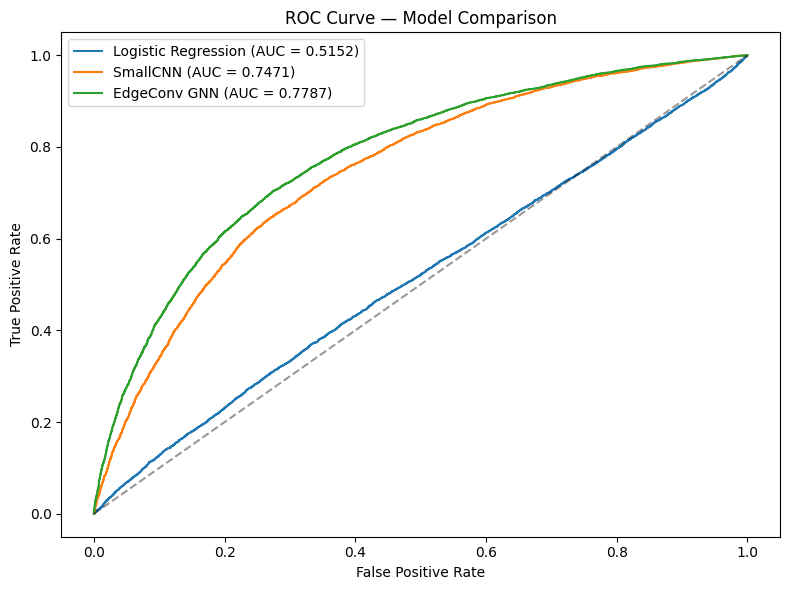

In [105]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_true, y_prob in [
    ("Logistic Regression", y_test_lr, y_prob_lr),
    ("SmallCNN", test_metrics_cnn["y_true"], test_metrics_cnn["y_prob"]),
    ("EdgeConv GNN", test_metrics_gnn["y_true"], test_metrics_gnn["y_prob"]),
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Model Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [106]:
print("EdgeConv GNN — Classification Report:")
print(classification_report(test_metrics_gnn["y_true"], test_metrics_gnn["y_pred"], digits=4))

EdgeConv GNN — Classification Report:
              precision    recall  f1-score   support

           0     0.7196    0.6940    0.7066     10448
           1     0.7045    0.7296    0.7169     10448

    accuracy                         0.7118     20896
   macro avg     0.7121    0.7118    0.7117     20896
weighted avg     0.7121    0.7118    0.7117     20896



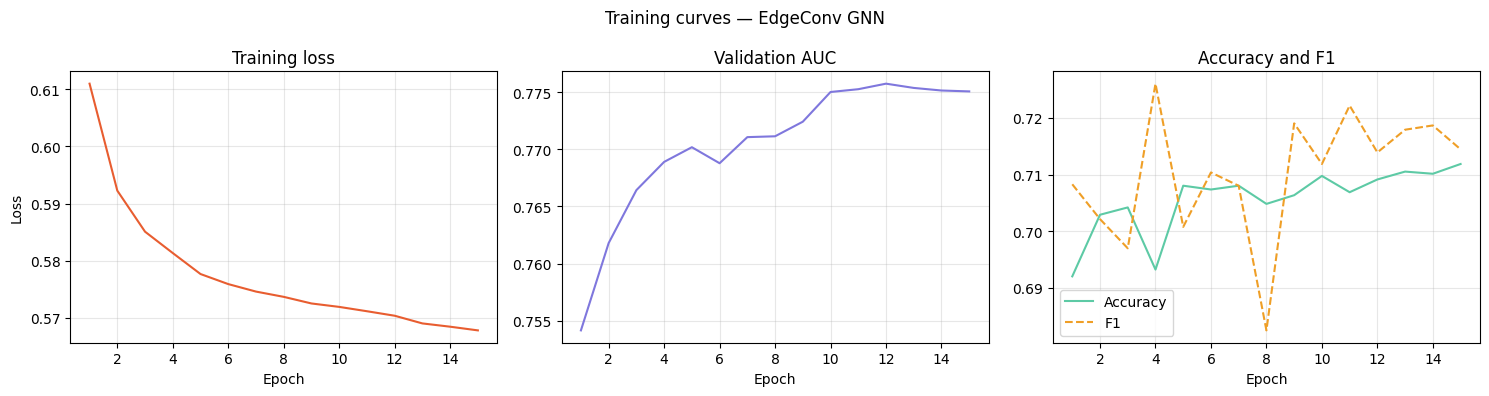

In [107]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], color="#E85D30")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["val_auc"], color="#7F77DD")
axes[1].set_title("Validation AUC")
axes[1].set_xlabel("Epoch")
axes[1].grid(alpha=0.3)

axes[2].plot(hist_df["epoch"], hist_df["val_acc"], color="#5DCAA5", label="Accuracy")
axes[2].plot(hist_df["epoch"], hist_df["val_f1"], color="#EF9F27", linestyle="--", label="F1")
axes[2].set_title("Accuracy and F1")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Training curves — EdgeConv GNN", fontsize=12)
plt.tight_layout()
plt.show()